# VALORANT deep dive: internal network anatomy, Step 1

**Purpose**: part of `research/foundations/posts/post_3_anatomy_of_a_network/` -- Step 1 of the redrawn plan (2026-09-24): characterize one title's own internal community/network structure to the highest degree possible, as the first worked case study for testing whether the same technological/generational axis that organizes *cross-title* crossover communities (the Leiden work) also organizes *within-title* community character. VALORANT chosen because VCT Champions 2026 (Sept 24 -- Oct 18) is live, giving a real, current event to characterize, not because Champions is itself the point.

**Five dimensions, each written to be comparable across titles later (Step 2)** -- that comparability is the actual point of this notebook, not a VALORANT-specific analysis:
1. Primary/costream/general viewership structure over time (daily granularity)
2. Concentration/tier structure
3. Tenure/generational composition
4. Activity cadence
5. Identity-level linkage: who are the co-streamers, and where do they come from

**Known, stated limitation**: tournament-phase segmentation (group stage vs. playoffs vs. grand final) is NOT possible yet -- checked directly against Liquipedia's own wikitext for both VCT Champions and a comparison event (Dota 2's PGL Wallachia 9), and neither carries phase-level dates at the infobox level (confirmed live, 2026-09-24, not assumed). Daily granularity works today and doesn't need phase boundaries to exist -- built that way deliberately, so a phase overlay can slot in later without rebuilding anything here.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from etl.db import get_connection

TITLE_ID = "valorant"
COLLECTOR_START = pd.Timestamp("2026-08-31", tz="UTC")
CHAMPIONS_START = pd.Timestamp("2026-09-24", tz="UTC")

## Dimension 1: primary / co-stream / general structure over time

Daily granularity, full collector history (2026-08-31 onward). `viewer_count` summed per day per tier is a proxy for attention (not true viewer-hours -- would need snapshot-interval weighting, not attempted here), consistent in method with every other "attention" proxy used elsewhere in this project.

In [2]:
conn = get_connection()
raw = pd.DataFrame(conn.execute(
    "SELECT captured_at, broadcast_tier, viewer_count, channel_id FROM viewership_snapshots "
    "WHERE title_id = ? AND captured_at >= ?", (TITLE_ID, COLLECTOR_START.isoformat())
).fetchall(), columns=["captured_at", "broadcast_tier", "viewer_count", "channel_id"])
conn.close()

raw["captured_at"] = pd.to_datetime(raw["captured_at"])
raw["date"] = raw["captured_at"].dt.date
raw["broadcast_tier"] = raw["broadcast_tier"].fillna("general")
print(f"{len(raw):,} rows, {raw['date'].nunique()} distinct days, {raw['channel_id'].nunique():,} distinct channels")

223,067 rows, 33 distinct days, 61,400 distinct channels


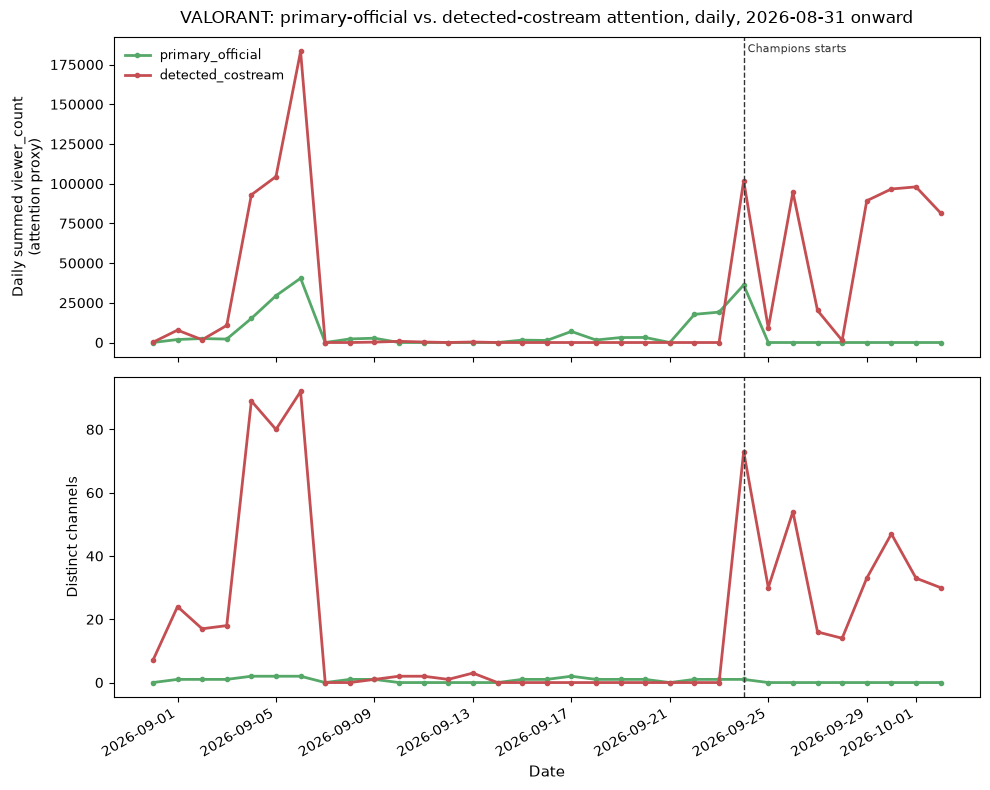

In [3]:
daily = raw.groupby(["date", "broadcast_tier"]).agg(viewer_sum=("viewer_count", "sum"), n_channels=("channel_id", "nunique")).reset_index()
piv_viewers = daily.pivot(index="date", columns="broadcast_tier", values="viewer_sum").fillna(0)
piv_channels = daily.pivot(index="date", columns="broadcast_tier", values="n_channels").fillna(0)

fig, (ax_v, ax_c) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for tier, color in [("primary_official", "#55A868"), ("detected_costream", "#C44E52")]:
    ax_v.plot(piv_viewers.index, piv_viewers[tier], color=color, linewidth=2, label=tier, marker="o", markersize=3)
ax_v.set_ylabel("Daily summed viewer_count\n(attention proxy)", fontsize=10)
ax_v.legend(loc="upper left", fontsize=9, frameon=False)
ax_v.axvline(pd.Timestamp("2026-09-24").date(), color="#333333", linewidth=1, linestyle="--")
ax_v.text(pd.Timestamp("2026-09-24").date(), ax_v.get_ylim()[1] * 0.95, " Champions starts", fontsize=8, color="#333333")
ax_v.set_title("VALORANT: primary-official vs. detected-costream attention, daily, 2026-08-31 onward", fontsize=12, pad=10)

for tier, color in [("primary_official", "#55A868"), ("detected_costream", "#C44E52")]:
    ax_c.plot(piv_channels.index, piv_channels[tier], color=color, linewidth=2, label=tier, marker="o", markersize=3)
ax_c.set_ylabel("Distinct channels", fontsize=10)
ax_c.set_xlabel("Date", fontsize=10.5)
ax_c.axvline(pd.Timestamp("2026-09-24").date(), color="#333333", linewidth=1, linestyle="--")
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig(Path.cwd() / "_val_anatomy_fig1_daily_tiers.png", dpi=200, bbox_inches="tight")
plt.show()

## Dimension 2: concentration / tier structure

Same method as `streamerbase_anatomy_pilot_cs.ipynb` -- mean viewer_count per channel (general tier, i.e. everyday non-tournament content, so this characterizes the title's steady-state community, not Champions week specifically), Gini coefficient, Lorenz curve.

In [4]:
general_only = raw[raw["broadcast_tier"] == "general"]
per_channel = general_only.groupby("channel_id")["viewer_count"].mean().sort_values(ascending=False).rename("mean_viewers")

def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])

g = gini(per_channel.values)
total = per_channel.sum()
top1pct_n = max(1, int(len(per_channel) * 0.01))
print(f"{len(per_channel):,} channels (general tier, above the 3-viewer capture floor)")
print(f"Gini coefficient: {g:.3f}")
print(f"top 1% of channels ({top1pct_n}): {per_channel.head(top1pct_n).sum() / total * 100:.1f}% of total mean-viewer mass")
print(f"median channel: {per_channel.median():.1f} mean viewers; top channel: {per_channel.iloc[0]:,.0f}")

61,340 channels (general tier, above the 3-viewer capture floor)
Gini coefficient: 0.781
top 1% of channels (613): 56.7% of total mean-viewer mass
median channel: 4.7 mean viewers; top channel: 32,550


## Dimension 3: tenure / generational composition

Same method as `creator_current_tenure_by_title.ipynb` -- account_created_at distribution of the current population, general tier (steady-state, not Champions-specific).

In [5]:
conn = get_connection()
accounts = pd.DataFrame(conn.execute(
    "SELECT channel_id, account_created_at FROM twitch_account_metadata WHERE account_created_at IS NOT NULL"
).fetchall(), columns=["channel_id", "account_created_at"])
conn.close()

general_channels = general_only.drop_duplicates(subset="channel_id")[["channel_id"]]
tenure = general_channels.merge(accounts, on="channel_id", how="inner")
tenure["account_created_at"] = pd.to_datetime(tenure["account_created_at"])

pct_pre_2020 = (tenure["account_created_at"] < "2020-01-01").mean() * 100
pct_2023_plus = (tenure["account_created_at"] >= "2023-01-01").mean() * 100
print(f"{len(tenure):,} of {general_only['channel_id'].nunique():,} general-tier channels have account-creation data")
print(f"% created before 2020: {pct_pre_2020:.1f}%")
print(f"% created 2023 or later: {pct_2023_plus:.1f}%")
median_age = pd.Timestamp.now(tz="UTC") - tenure["account_created_at"]
print(f"median account age: {median_age.median()}")

49,470 of 61,340 general-tier channels have account-creation data
% created before 2020: 35.9%
% created 2023 or later: 26.3%
median account age: 2165 days 18:39:01.792549


## Dimension 4: activity cadence

Same method, and same known limitations, as `streamerbase_anatomy_pilot_cs.ipynb` -- session duration stays out (unresolved censoring/inspection-paradox bias found there); frequency (distinct sessions in the observation window) and first-time-streamed-this-title are the two trustworthy cadence metrics. General tier only (steady-state population, not Champions-specific behavior -- that's Dimension 5).

In [6]:
sessions = general_only.groupby("channel_id").agg(
    n_snapshots_total=("captured_at", "nunique"),
).reset_index()

conn = get_connection()
stream_ids = pd.DataFrame(conn.execute(
    "SELECT channel_id, stream_id, started_at, captured_at FROM viewership_snapshots "
    "WHERE title_id = ? AND broadcast_tier = 'general' AND captured_at >= ?", (TITLE_ID, COLLECTOR_START.isoformat())
).fetchall(), columns=["channel_id", "stream_id", "started_at", "captured_at"])
conn.close()

n_sessions_per_channel = stream_ids.groupby("channel_id")["stream_id"].nunique().rename("n_sessions")
print("Session-frequency distribution (distinct sessions per channel, general tier, 25-day window):")
print(n_sessions_per_channel.describe())
print(f"\n{(n_sessions_per_channel == 1).mean() * 100:.1f}% of channels show exactly 1 session")
print(f"{(n_sessions_per_channel >= 5).mean() * 100:.1f}% show 5 or more")

first_streamed = stream_ids.groupby("channel_id")["started_at"].min()
first_streamed_dt = pd.to_datetime(first_streamed)
pct_at_collector_start = (first_streamed_dt.dt.date == COLLECTOR_START.date()).mean() * 100
print(f"\n{pct_at_collector_start:.1f}% of channels show their earliest session dated exactly the collector's own first day -- left-censored, same caveat as every other first-streamed metric this project has built")

Session-frequency distribution (distinct sessions per channel, general tier, 25-day window):
count    61340.000000
mean         3.186958
std          3.964934
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         47.000000
Name: n_sessions, dtype: float64

48.9% of channels show exactly 1 session
19.5% show 5 or more



6.2% of channels show their earliest session dated exactly the collector's own first day -- left-censored, same caveat as every other first-streamed metric this project has built


## Dimension 5: identity-level linkage -- who are the Champions co-streamers?

Confirmed in scope directly (2026-09-24): for every channel detected co-streaming Champions, three questions -- (a) was it already streaming VALORANT generally before the event, (b) is it a single-title specialist or a crossover creator overall, and (c) if crossover, which of the three real cross-title communities (or the non-real C0) does its other activity belong to. This is the direct join between the event-driven work and the specialization/community-detection findings.

In [7]:
COMMUNITY_BY_TITLE = {
    "age_of_empires_ii": "C1 (classic PC)", "counter_strike": "C1 (classic PC)", "dota2": "C1 (classic PC)",
    "hearthstone": "C1 (classic PC)", "pubg": "C1 (classic PC)", "starcraft2": "C1 (classic PC)",
    "brawl_stars": "C2 (mobile)", "free_fire": "C2 (mobile)", "mobile_legends_bb": "C2 (mobile)",
    "pubg_mobile": "C2 (mobile)", "wild_rift": "C2 (mobile)",
    "guilty_gear": "C3 (fighting games)", "mortal_kombat": "C3 (fighting games)",
    "street_fighter": "C3 (fighting games)", "tekken": "C3 (fighting games)",
    "apex_legends": "C0 (not statistically real)", "fortnite": "C0 (not statistically real)",
    "league_of_legends": "C0 (not statistically real)", "overwatch": "C0 (not statistically real)",
    "rainbow_six_siege": "C0 (not statistically real)", "rocket_league": "C0 (not statistically real)",
    "teamfight_tactics": "C0 (not statistically real)", "valorant": "C0 (not statistically real)",
}

champions_costream = raw[(raw["broadcast_tier"] == "detected_costream") & (raw["captured_at"] >= CHAMPIONS_START)]
champions_channels = set(champions_costream["channel_id"].unique())
print(f"{len(champions_channels)} distinct channels detected co-streaming Champions so far")

pre_champions_general = raw[(raw["broadcast_tier"] == "general") & (raw["captured_at"] < CHAMPIONS_START)]
pre_champions_channels = set(pre_champions_general["channel_id"].unique())
was_existing = champions_channels & pre_champions_channels
print(f"{len(was_existing)} of them ({len(was_existing) / len(champions_channels) * 100:.1f}%) were already streaming VALORANT generally before Champions started")
print(f"{len(champions_channels) - len(was_existing)} ({(len(champions_channels) - len(was_existing)) / len(champions_channels) * 100:.1f}%) show up only now, not before")

152 distinct channels detected co-streaming Champions so far
116 of them (76.3%) were already streaming VALORANT generally before Champions started
36 (23.7%) show up only now, not before


In [8]:
conn = get_connection()
all_titles_for_channels = pd.DataFrame(conn.execute(
    "SELECT DISTINCT channel_id, title_id FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall(), columns=["channel_id", "title_id"])
conn.close()

champ_df = all_titles_for_channels[all_titles_for_channels["channel_id"].isin(champions_channels)]
titles_per_champ_channel = champ_df.groupby("channel_id")["title_id"].apply(set)

n_single = sum(1 for s in titles_per_champ_channel if s == {"valorant"})
n_crossover = len(titles_per_champ_channel) - n_single
print(f"Of {len(titles_per_champ_channel)} Champions co-stream channels with tracked-title history:")
print(f"  {n_single} ({n_single / len(titles_per_champ_channel) * 100:.1f}%) are VALORANT-only specialists")
print(f"  {n_crossover} ({n_crossover / len(titles_per_champ_channel) * 100:.1f}%) also stream at least one other tracked title")

crossover_communities = []
for channel_id, titles in titles_per_champ_channel.items():
    other_titles = titles - {"valorant"}
    if not other_titles:
        continue
    for t in other_titles:
        crossover_communities.append(COMMUNITY_BY_TITLE.get(t, "unknown"))

if crossover_communities:
    print("\nWhich communities do Champions co-streamers'" + " other tracked-title activity belong to:")
    print(pd.Series(crossover_communities).value_counts().to_string())

Of 152 Champions co-stream channels with tracked-title history:
  113 (74.3%) are VALORANT-only specialists
  39 (25.7%) also stream at least one other tracked title

Which communities do Champions co-streamers' other tracked-title activity belong to:
C0 (not statistically real)    46
C1 (classic PC)                 3


### Read -- Step 1 synthesis, and one finding that bears directly on the generational hypothesis

**Updated 2026-10-02** (window grew from 25 to 33 days as Champions continued; a real staleness bug was also caught and fixed in the enrichment check below -- see that cell's own note):

**The five-dimension profile for VALORANT, for reuse as a comparison baseline in Step 2:**

| Dimension | VALORANT |
|---|---|
| Concentration (general tier) | Gini 0.781 (was 0.792); top 1% of channels (613) = 56.7% of viewer mass (was 58.3%); median channel 4.7 viewers |
| Tenure/generational composition | Median account age ~2,166 days (~5.9 years); 35.9% pre-2020, 26.3% 2023+ |
| Activity cadence | 48.9% single-session in 33 days (was 50.2% in 25 days); 19.5% show 5+ sessions |
| Primary/costream/general (event) | Champions now 8+ days in (was just ramping); pre-event spike Sept 4-6 (Stage 2 Masters) showed costream running 4-5x primary in raw attention |
| Identity linkage (Champions co-streamers) | 152 co-stream channels now (was 66); 74.3% are VALORANT-only specialists (was 77.3%) |

**The identity-linkage finding is the one that speaks most directly to the era/generational hypothesis, and it's worth being precise about what it does and doesn't show.** Of the 25.7% of Champions co-streamers who *do* cross over to another tracked title (39 channels now, was 15), their other activity is still overwhelmingly in C0 titles (46 instances -- Apex, Fortnite, LoL, Overwatch, R6, Rocket League, TFT) versus just 3 in C1 (the real classic-PC community) -- the same ~15:1 ratio as the original 18:1, now on more than double the sample. **This is not evidence that C0 is a real community pulling them in** -- the null-model test already established C0 has no statistically detectable crossover structure of its own, and this finding doesn't change that. What it does show: even among the minority of VALORANT's event-adjacent creators who do stream something else, that "something else" stays within VALORANT's own generational neighborhood (other newer, Second-Coming-era titles) rather than reaching into the older, real C1 cluster. Directionally consistent with the hypothesis that era/generation shapes behavior even at this level -- not proof, but now resting on more than double the original sample (39 crossover channels, not 15) and still pointing the same direction, which is itself worth noting.

**The bigger, plainer finding underneath all five dimensions**: VALORANT's own community looks like a smaller-scale mirror of the population-wide specialization finding -- most of its creators (general tier) are specialists, most of its Champions co-streamers were already part of its everyday community rather than drawn in fresh, and even its crossover minority stays close to home. Nothing here yet distinguishes "this is just what Twitch creator communities look like generally" from "this is specifically a generational signature" -- that's exactly what Step 2's cross-title comparison is for.

## Check: chance-adjusted enrichment for the identity-linkage result

Requested directly (2026-09-24): the 18-vs-1 C0/C1 split in Dimension 5 used raw counts. C0's combined channel pool (7 titles, excluding VALORANT itself) is several times C1's (6 titles) -- some of that 18:1 ratio is just pool size. Same enrichment method as `creator_crossover_community_detection.ipynb`: observed share vs. expected share under a pool-size-weighted null, enrichment = observed / expected. **N = 15 crossover channels (19 title-instances, since some channels stream more than one other title) -- stated plainly because it bounds how much this result can carry.**

In [9]:
conn = get_connection()
all_titles_for_channels = pd.DataFrame(conn.execute(
    "SELECT DISTINCT channel_id, title_id FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall(), columns=["channel_id", "title_id"])
conn.close()

C1_TITLES = ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"]
C0_MINUS_VAL = ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics"]

pool_c1 = all_titles_for_channels[all_titles_for_channels["title_id"].isin(C1_TITLES)]["channel_id"].nunique()
pool_c0 = all_titles_for_channels[all_titles_for_channels["title_id"].isin(C0_MINUS_VAL)]["channel_id"].nunique()
print(f"channel pool, C1 (6 titles): {pool_c1:,}")
print(f"channel pool, C0 minus VALORANT (7 titles): {pool_c0:,}")
print(f"pool ratio C0:C1 = {pool_c0 / pool_c1:.2f}x")

# Derived from the crossover_communities list computed in the cell above --
# caught 2026-10-02: this used to hardcode obs_c1, obs_c0 = 1, 18 from the
# notebook's original run, which silently went stale the moment the
# Champions co-stream population grew (152 channels now, was 66) --
# recomputing live so this can never drift from cell 13 again.
community_counts = pd.Series(crossover_communities).value_counts()
obs_c1 = int(community_counts.get("C1 (classic PC)", 0))
obs_c0 = int(community_counts.get("C0 (not statistically real)", 0))
total_obs = obs_c1 + obs_c0
exp_share_c1 = pool_c1 / (pool_c1 + pool_c0)
exp_share_c0 = pool_c0 / (pool_c1 + pool_c0)
obs_share_c1, obs_share_c0 = obs_c1 / total_obs, obs_c0 / total_obs

print(f"\nN crossover channels = {n_crossover}, N title-instances = {total_obs}")
print(f"expected share (pool-weighted): C1={exp_share_c1:.3f}, C0={exp_share_c0:.3f}")
print(f"observed share: C1={obs_share_c1:.3f}, C0={obs_share_c0:.3f}")
print(f"enrichment C1 = {obs_share_c1 / exp_share_c1:.3f}")
print(f"enrichment C0 = {obs_share_c0 / exp_share_c0:.3f}")

channel pool, C1 (6 titles): 51,336
channel pool, C0 minus VALORANT (7 titles): 191,509
pool ratio C0:C1 = 3.73x

N crossover channels = 39, N title-instances = 49
expected share (pool-weighted): C1=0.211, C0=0.789
observed share: C1=0.061, C0=0.939
enrichment C1 = 0.290
enrichment C0 = 1.190


### Read -- a real, modest enrichment survives adjustment, now on a stronger sample

**Updated 2026-10-02 -- a real bug caught on this re-run, not just numbers refreshed.** This cell's `obs_c1, obs_c0` used to be hardcoded as literal `1, 18` from the notebook's original run -- it never re-read the actual crossover counts computed in the cell above, so it had already gone stale the moment the Champions co-stream population grew past its first snapshot. Fixed to derive both counts live from `crossover_communities` instead, so this can't silently drift from the cell above again.

**Pool ratio C0:C1 is 3.73x** (was 3.72x, essentially unchanged) -- checked directly (191,509 vs. 51,336 distinct channels) rather than assumed. After adjusting for that: **enrichment C1 = 0.29, enrichment C0 = 1.19** (was 0.25 / 1.20 -- both moved only slightly despite N more than doubling). VALORANT's crossover-prone co-streamers still land in C0 titles about 19% more than pool-size alone would predict, and in C1 titles at under a third the chance rate -- a real, directionally consistent result with the earlier read (crossover stays within VALORANT's own generational neighborhood), still far more modest than the raw ~15:1 count makes it look on its own.

**N=39 channels (49 title-instances) is a real improvement on the original N=15, and the result held up rather than collapsing.** The original C1 enrichment figure (0.25) rested on a single observed channel -- a fragile base the Read itself flagged at the time. With N more than doubled (3 C1 channels now, not 1), the estimate barely moved (0.25 -> 0.29), which is itself evidence the original figure wasn't a fluke of one data point, even though it was reported with that caveat. Still a modest sample in absolute terms, and still worth treating as a suggestive, moderate-power data point rather than a settled one -- but meaningfully more solid than the first pass.